In [2]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
data_path = "/media/apollo/projects/hc-18/data/"

os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import ripple_detection as ripple
import normalizing_functions as norm
import helper_functions as helper
import bootstrapped_estimation as bootstrap


sessions = ['Train-242-20140124','Train-261-20140617','Train-272-20141215','Train-292-20150501','Train-314-20160118']
animals = ['242','261','272','292','314']


In [2]:
event_name = 'SleepBaseline'
# event_name = 'PassiveForward'
    
output_dict = dict()
output_dict['rat'] = []
output_dict['session'] = []
output_dict['side'] = []
output_dict['shank_1'] = []
output_dict['shank_2'] = []
output_dict['phase_phase_coupling'] = []
output_dict['phase_phase_direction'] = []

srate = 1250.
ripple_threshold_level = 2
ripple_low_freq = 100
ripple_high_freq = 250
minimum_ripple_length = 0.03*srate
smooth_points = 0.001*srate

for animal_idx,session in enumerate(sessions):

    print(session)
    
    lfp,srate = hc18_bf.load_lfp_hc18_data(session)
    
    event_times, event_descriptions = hc18_bf.get_events(session, event_name)
    
    event_times = np.sort(np.array(event_times))
    event_start = np.nanmin(event_times)
    event_end = np.nanmax(event_times)
    print(event_start)
    print(event_end)

    shanks_electrodes,left_shanks,right_shanks = hc18_bf.get_shanks_info(session)

    file_path = f'{data_path}/{session}/'
    filename = f'{session}_{event_name}_sws_epoch'
    sleep_epochs = np.load(file_path + filename)
    lfp = lfp[:,sleep_epochs]
    # lfp = np.double(lfp[:,sleep_epochs])
    # lfp = sig.detrend(helper.eegfilt(lfp,srate,1,300))

    max_ripple_channels = []
    for channels in shanks_electrodes:
        if len(channels) > 0:
            ripple_lfp = lfp[channels,:]
            ripple_filtered = sig.detrend(helper.eegfilt(ripple_lfp,srate,100,250))
            ripple_amp = np.abs(helper.hilbert(ripple_filtered))
    
            max_ripple_idx = np.argmax(np.nanmean(ripple_amp,1))
            max_ripple_channels.append(channels[max_ripple_idx])
    
        else:
            max_ripple_channels.append(np.nan)
    max_ripple_channels = np.array(max_ripple_channels)
    del ripple_filtered, ripple_amp
    
    for shank_1 in np.arange(0,len(shanks_electrodes)-1):    
        
        print('Shank 1 = ' + str(shank_1))
        ripple_channel_1 = max_ripple_channels[shank_1]
        if np.isnan(ripple_channel_1):
            continue

        ripple_lfp_1 = lfp[int(ripple_channel_1),:]

        ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
        ripple_hilbert_1 = helper.hilbert(ripple_filtered_1)
        ripple_phase_1 = np.angle(ripple_hilbert_1)
        # ripple_amp_1 = np.abs(ripple_hilbert_1)

        for shank_2 in np.arange(shank_1+1,len(shanks_electrodes)):
                
            ripple_channel_2 = max_ripple_channels[shank_2]
            if np.isnan(ripple_channel_2):
                continue
            
            ripple_lfp_2 = lfp[int(ripple_channel_2),:]
            ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))
            ripple_hilbert_2 = helper.hilbert(ripple_filtered_2)
            ripple_phase_2 = np.angle(ripple_hilbert_2)
            # ripple_amp_2 = np.abs(ripple_hilbert_2)

            ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_1)-np.unwrap(ripple_phase_2)))

            phasediff_r = np.abs(np.nanmean(ripple_phase_diff))
            mean_phasediff = np.angle(np.nanmean(ripple_phase_diff))

            if ((shank_1 in left_shanks) & (shank_2 in left_shanks)) | ((shank_1 in right_shanks) & (shank_2 in right_shanks)):
                side = 'ipsi'
            else:
                side = 'contra'
            
            output_dict['rat'].append(animals[animal_idx])
            output_dict['session'].append(session)
            output_dict['side'].append(side)
            output_dict['shank_1'].append(shank_1)
            output_dict['shank_2'].append(shank_2)
            output_dict['phase_phase_coupling'].append(phasediff_r)
            output_dict['phase_phase_direction'].append(mean_phasediff)
            
df = pd.DataFrame(output_dict)
df

path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

df.to_csv('Figure_Ripple_PhasePhaseCoupling_WholeSignal_hc18.csv',index=False)


Train-242-20140124


FileNotFoundError: [Errno 2] No such file or directory: '/media/apollo/projects/hc-18/data/Train-242-20140124'

In [3]:
import pandas as pd

path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)
df = pd.read_csv('Figure_Ripple_PhasePhaseCoupling_WholeSignal_hc18.csv')
df

,rat,session,side,shank_1,shank_2,phase_phase_coupling,phase_phase_direction
0,242,Train-242-20140124,ipsi,0,1,0.372677,-0.294977
1,242,Train-242-20140124,ipsi,0,2,0.322364,-0.058451
2,242,Train-242-20140124,ipsi,0,3,0.350113,-0.111991
3,242,Train-242-20140124,ipsi,0,4,0.289865,-0.048621
4,242,Train-242-20140124,ipsi,0,5,0.347345,-0.107547
...,...,...,...,...,...,...,...
238,314,Train-314-20160118,ipsi,11,13,0.215157,0.570859
239,314,Train-314-20160118,ipsi,11,15,0.169741,0.364551
240,314,Train-314-20160118,ipsi,12,13,0.490396,0.135234
241,314,Train-314-20160118,ipsi,12,15,0.334293,0.228876


/tmp/ipykernel_16822/1232785858.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


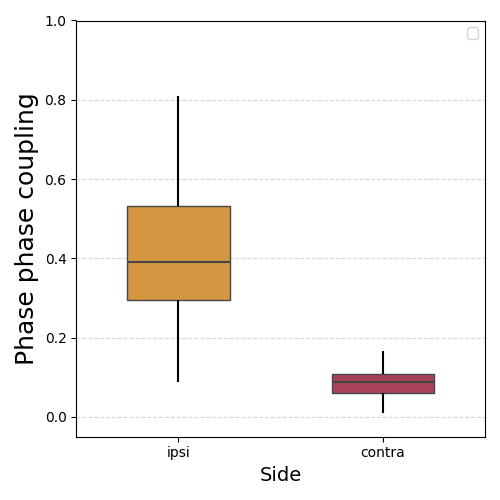

In [4]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

# sns.stripplot(data=df, x="side", y="phase_phase_coupling", hue='side',
#               order=["ipsi", "contra"], palette=my_pal,size=6,alpha=1)

box = sns.boxplot(data=df, x="side", y="phase_phase_coupling", hue='side',
            order=['ipsi','contra'], showfliers=True, showcaps=False,palette=my_pal,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette

# ax=sns.violinplot(data=df,x="side", y="phase_phase_coupling", hue='side',
#                 order=["ipsi", "contra"], palette=my_pal,fill=True,inner = None,\
#                 split=True, density_norm='width',saturation=1,bw_adjust=0.5,native_scale=True)
# plt.setp(ax.collections, alpha=.3)

plt.ylabel('Phase phase coupling',fontsize=18)
plt.xlabel('Side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
plt.ylim([-0.05,1])
plt.legend()
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

# os.chdir(figures_path + '/figure_3/')
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal.svg'
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_RippleEvents.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fi_name)



In [12]:

phase_phase_ipsi = []
phase_phase_contra = []
for animal in animals:
    df_slice = df[df['rat'] == int(animal)]
    aux_ipsi = np.nanmean(df_slice[df_slice['side'] == 'ipsi']['phase_phase_coupling'])
    phase_phase_ipsi.append(aux_ipsi)
    aux_contra = np.nanmean(df_slice[df_slice['side'] == 'contra']['phase_phase_coupling'])
    phase_phase_contra.append(aux_contra)

phase_phase_ipsi = np.array(phase_phase_ipsi)
phase_phase_contra = np.array(phase_phase_contra)


In [13]:
phase_phase_ipsi

array([0.43835506, 0.38487435, 0.44966933, 0.37204899, 0.41909414])

In [14]:
phase_phase_contra

array([0.10459033, 0.03164787, 0.09909411, 0.06821245, 0.0993471 ])

In [15]:

observed_g = bootstrap.hedges_g(phase_phase_ipsi,phase_phase_contra, paired=True)

bootstrapped_g, ci_bounds = bootstrap.bootstrap_hedges_g(phase_phase_ipsi,phase_phase_contra, n_bootstraps=5000, ci=95, paired=True)

observed_g, shuffled_g, p_value = bootstrap.pvalue_hedges_g_permutation(phase_phase_ipsi,phase_phase_contra, n_permutations=5000, ci=95, paired=True)


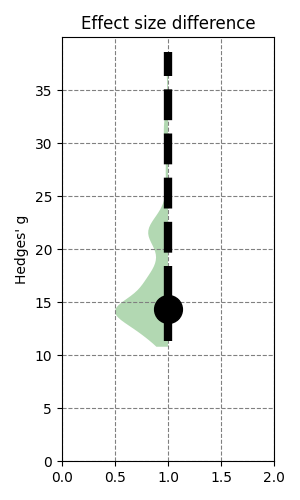

In [16]:
# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = np.percentile(bootstrapped_g, 25)
Q3 = np.percentile(bootstrapped_g, 75)

# Compute interquartile range (IQR)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR  # Anything below this is an outlier
upper_bound = Q3 + 1.5 * IQR  # Anything above this is an outlier

lower_bound = np.nanmin([Q1 - 1.5 * IQR,np.percentile(bootstrapped_g, 2.5)])
upper_bound = np.nanmax([Q3 + 1.5 * IQR,np.percentile(bootstrapped_g, 97.5)])

# Filter out outliers
filtered_g_values = [g for g in bootstrapped_g if lower_bound <= g <= upper_bound]


plt.figure(figsize=(3,5))
violin_parts = plt.violinplot(filtered_g_values,showmeans=False,showextrema=False,side='low',positions=[1],widths=1)
for pc in violin_parts['bodies']:
    pc.set_facecolor('green')
# plt.boxplot(filtered_g_values,positions=[2])
   
plt.plot([1,1],ci_bounds,color='black',lw=6,ls='--')
plt.plot(1,observed_g,color='black',ls='',marker='o',markersize=20)
plt.plot()
plt.ylabel("Hedges' g")
plt.grid(ls='--',color='gray')
plt.xlim([0,2])
# plt.ylim([0,5])
plt.ylim(bottom=0)
plt.title('Effect size difference')
plt.tight_layout()
plt.show()


In [17]:
import bootstrapped_estimation as bootstrap
phase_phase_ipsi = []
phase_phase_contra = []
for animal in animals:
    df_slice = df[df['rat'] == int(animal)]
    phase_phase_ipsi.append(df_slice[df_slice['side'] == 'ipsi']['phase_phase_coupling'].values)
    phase_phase_contra.append(df_slice[df_slice['side'] == 'contra']['phase_phase_coupling'].values)
phase_phase_ipsi = np.concatenate(phase_phase_ipsi)
phase_phase_contra = np.concatenate(phase_phase_contra)    


In [18]:

observed_g = bootstrap.hedges_g(phase_phase_ipsi,phase_phase_contra, paired=False)

bootstrapped_g, ci_bounds = bootstrap.bootstrap_hedges_g(phase_phase_ipsi,phase_phase_contra, n_bootstraps=5000, ci=95, paired=False)

observed_g, shuffled_g, p_value = bootstrap.pvalue_hedges_g_permutation(phase_phase_ipsi,phase_phase_contra, n_permutations=5000, ci=95, paired=False)


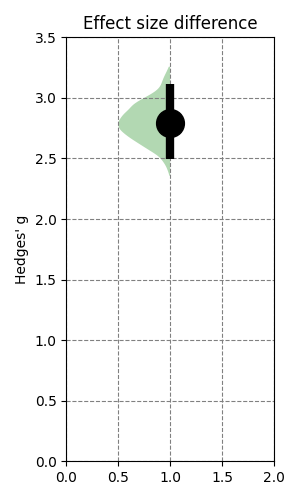

In [19]:
# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = np.percentile(bootstrapped_g, 25)
Q3 = np.percentile(bootstrapped_g, 75)

# Compute interquartile range (IQR)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR  # Anything below this is an outlier
upper_bound = Q3 + 1.5 * IQR  # Anything above this is an outlier

lower_bound = np.nanmin([Q1 - 1.5 * IQR,np.percentile(bootstrapped_g, 2.5)])
upper_bound = np.nanmax([Q3 + 1.5 * IQR,np.percentile(bootstrapped_g, 97.5)])

# Filter out outliers
filtered_g_values = [g for g in bootstrapped_g if lower_bound <= g <= upper_bound]


plt.figure(figsize=(3,5))
violin_parts = plt.violinplot(filtered_g_values,showmeans=False,showextrema=False,side='low',positions=[1],widths=1)
for pc in violin_parts['bodies']:
    pc.set_facecolor('green')
# plt.boxplot(filtered_g_values,positions=[2])
   
plt.plot([1,1],ci_bounds,color='black',lw=6,ls='--')
plt.plot(1,observed_g,color='black',ls='',marker='o',markersize=20)
plt.plot()
plt.ylabel("Hedges' g")
plt.grid(ls='--',color='gray')
plt.xlim([0,2])
plt.ylim([0,3.5])
# plt.ylim(bottom=0)

plt.title('Effect size difference')
plt.tight_layout()
plt.show()
